# EDA

In [19]:
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from common.paths import get_data_raw_dpath
from common.logger import JUPYTER_LOGGER as logger

In [39]:
synth_df = pd.read_csv(get_data_raw_dpath() / 'mistral_judged_dataset2.csv')
synth_df.head()

,dataset_name,query,correct_answer,model_answer,judge_score,is_hallucination
0,rubq-20,Какой стране принадлежит знаменитый остров Пасхи?,Чили,Знаменитый остров Пасхи (Рапа-Нуи) принадлежит...,не галлюцинация,0
1,rubq-20,С какой музыкальной группой неразрывно связано...,'Роллинг Стоунз',Имя **Мика Джаггера** неразрывно связано с лег...,не галлюцинация,0
2,rubq-20,Где находится Летний сад?,Санкт-Петербург,"Летний сад находится в Санкт-Петербурге, Росси...",не галлюцинация,0
3,rubq-20,Какой город является столицей Туркмении?,Ашхабад,Столицей Туркмении является город **Ашхабад** ...,не галлюцинация,0
4,rubq-20,В каком городе издавалась с 1857 г. А. Герцено...,Лондон,"Первая российская революционная газета ""Колоко...",не галлюцинация,0


C:\Users\User\AppData\Local\Temp\ipykernel_19212\164923396.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.index, y=vc.values, palette='viridis')


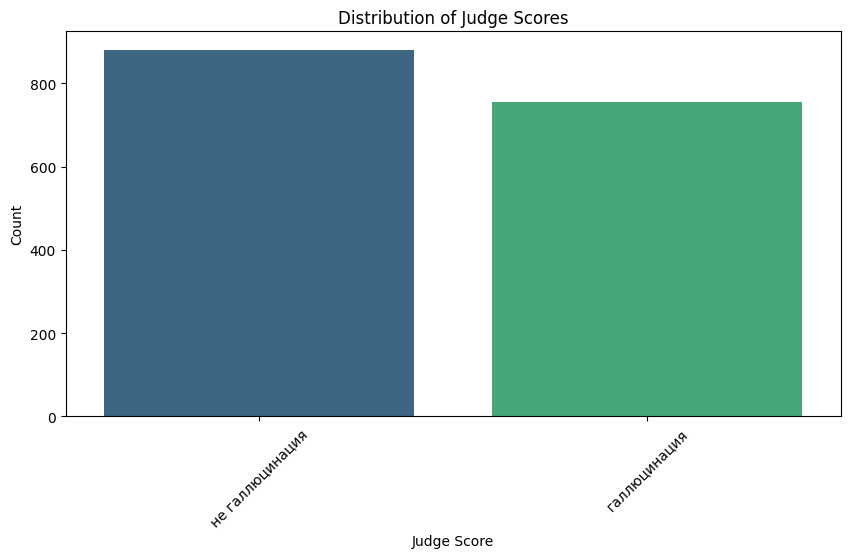

In [40]:
vc = synth_df['judge_score'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc.index, y=vc.values, palette='viridis')
plt.title('Distribution of Judge Scores')
plt.xlabel('Judge Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [41]:
# samples with judge_score == "галлюцинация"

hallucination_samples = synth_df[synth_df['judge_score'] == "галлюцинация"]
logger.info(f'Number of hallucination samples: {len(hallucination_samples)}')
hallucination_samples

2026-04-05 04:20:03,252 - jupyter-notebooks - INFO - [JUPYTER 📓] Number of hallucination samples: 755


,dataset_name,query,correct_answer,model_answer,judge_score,is_hallucination
29,rubq-20,Какому государству принадлежит народный парк Б...,Польша,Народный парк **Беловежская пуща** расположен ...,галлюцинация,1
34,rubq-20,Как звали доктора Ватсона?,Джон,Доктор Ватсона звали **Джон Хеммиш Ватсон** (J...,галлюцинация,1
40,rubq-20,"Кто написал поэму ""Ода к радости""?",Фридрих Шиллер,"Поэму **""Ода к радости""** (нем. **""An die Freu...",галлюцинация,1
64,rubq-20,Как теперь называется Порт-Артур?,Люйшунь,"Порт-Артур — это историческое название города,...",галлюцинация,1
95,rubq-20,"В каком городе проводился фестиваль ""Рок над В...",Самара,"Фестиваль ""Рок над Волгой"" проводился в городе...",галлюцинация,1
...,...,...,...,...,...,...
1628,tape-multiq.raw,"В какой лиге играет команда, тренером которой ...",английскую Премьер-лигу,Нуну Эшпириту Санту в настоящее время является...,галлюцинация,1
1629,tape-multiq.raw,"В какой лиге играет команда, тренера которой з...",английской Премьер-лиги,На данный момент (июнь 2024 года) **Уоррен Джо...,галлюцинация,1
1632,tape-multiq.raw,"В какой лиге играет команда, тренера которой з...",Премьер-Лиге Сенегала,На данный момент (июнь 2024 года) Амара Траоре...,галлюцинация,1
1633,tape-multiq.raw,"В какой лиге играет команда, за тренировки кот...","MLS, высшей футбольной лиге США и Канады","Команда, за тренировки которой отвечает Оскар ...",галлюцинация,1


# Concat with original dataset

In [42]:
original_df = pd.read_csv(get_data_raw_dpath() / 'features_with_judge_scores.csv')

common_cols = synth_df.columns.to_list()
common_cols.remove('dataset_name')

merged_df = pd.concat([original_df[common_cols], synth_df[common_cols]], ignore_index=True)
merged_df = merged_df.drop_duplicates(subset=['query']).reset_index(drop=True)
merged_df = merged_df.dropna(subset=['judge_score'])
merged_df['judge_score'] = merged_df['judge_score'].apply(
    lambda x: x == "галлюцинация" or x is True
)
logger.info(f'Merged dataset shape: {merged_df.shape}')
merged_df.head()

2026-04-05 04:20:10,547 - jupyter-notebooks - INFO - [JUPYTER 📓] Merged dataset shape: (2948, 5)


,query,correct_answer,model_answer,judge_score,is_hallucination
0,"ЭТОГО православного святого иногда называют ""м...",Федор УШАКОВ,Святого Николая Чудотворца иногда называют «мо...,True,1
1,"Где родился создатель музыки к фильму ""Крадено...",Каламата,Создателем музыки к фильму «Краденое небо» явл...,True,1
2,"Именно ему мы так верили, ""как, может быть, не...",Жириновскому,Эта фраза — цитата из романа Михаила Булгакова...,True,1
3,В этой знаменитой российской иерархии было 14 ...,"В ""Табели о рангах""","Вероятно, вы имеете в виду «Иерархию» — знамен...",True,1
4,"Согласно Большому толковому словарю, это — ""не...","Стопка. Зачет: Стопарь, стопарик",Это слово - *штоф*. \r\n\r\nШтоф — это небольш...,True,1


C:\Users\User\AppData\Local\Temp\ipykernel_19212\2397380612.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_js_merged.index, y=vc_js_merged.values, palette='viridis')


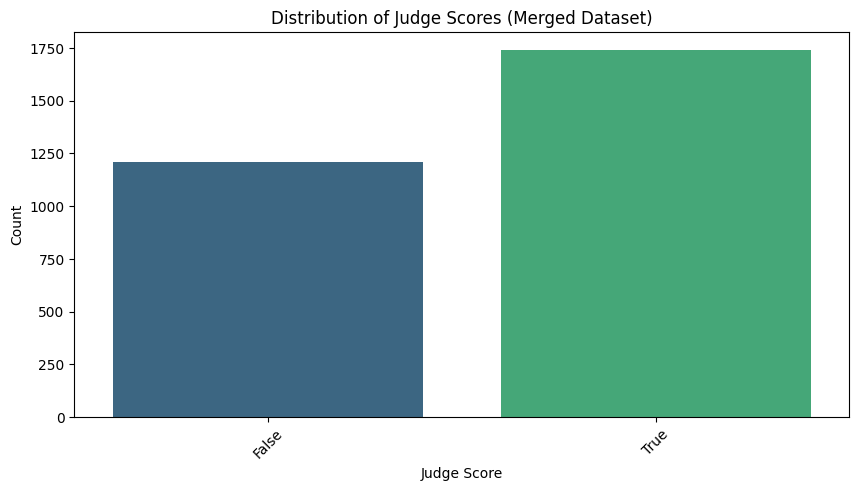

In [43]:
vc_js_merged = merged_df['judge_score'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc_js_merged.index, y=vc_js_merged.values, palette='viridis')
plt.title('Distribution of Judge Scores (Merged Dataset)')
plt.xlabel('Judge Score')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_19212\1686442706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc_is_hallucination.index, y=vc_is_hallucination.values, palette='viridis')


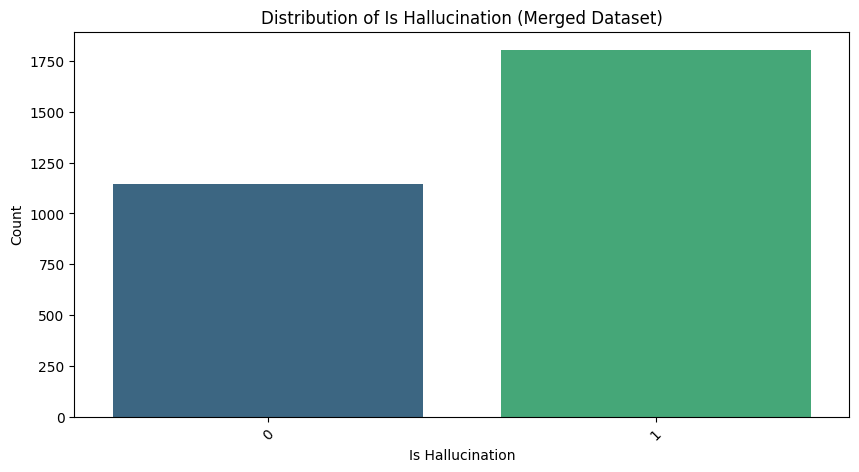

In [44]:
vc_is_hallucination = merged_df['is_hallucination'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=vc_is_hallucination.index, y=vc_is_hallucination.values, palette='viridis')
plt.title('Distribution of Is Hallucination (Merged Dataset)')
plt.xlabel('Is Hallucination')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [45]:
merged_df.to_csv(get_data_raw_dpath() / 'merged_dataset.csv', index=False)